# Μηνιαίοι Δείκτες KPI Δικτύου Τηλεπικοινωνιών: Ράβδοι Χρήσης Δεδομένων με Γραμμές ARPU και Αποχώρησης (PROC GBARLINE)

## Περίληψη

Αυτό το notebook χρησιμοποιεί την **PROC GBARLINE** για να συνδυάσει ένα κάθετο ραβδόγραμμα μηνιαίας χρήσης κινητών δεδομένων με επικαλυπτόμενα γραφήματα γραμμών ARPU, αποχώρησης, και αιτημάτων υποστήριξης — το κλασικό dashboard KPI «δύο αξόνων» που κατασκευάζει ένας αναλυτής τηλεπικοινωνιών για να εντοπίσει αν η αυξανόμενη χρήση μεταφράζεται πραγματικά σε έσοδα και διατήρηση πελατών. Δημιουργεί συνθετικές εγγραφές ανά συνδρομητή εσωτερικά, και στη συνέχεια ασκεί τις δηλώσεις BAR και LINE με υποομάδες, προσαρμοσμένους δεξιούς άξονες, σύμβολα αναφοράς, και υπομνήματα.

## Πηγές Δεδομένων

**Σύνολο δεδομένων: `telco_kpi`** — συνθετικές εγγραφές ανά συνδρομητή-μήνα (4 μήνες x 3 επίπεδα προγράμματος x 8 συνδρομητές = 96 γραμμές), δημιουργημένες εσωτερικά με `call streaminit(20260531)`. Το πάνελ διατηρείται στις 96 γραμμές ώστε να χωράει άνετα εντός του ορίου 100 παρατηρήσεων της μη αδειοδοτημένης λειτουργίας, αφήνοντας κάθε μήνα και επίπεδο προγράμματος πλήρως συμπληρωμένο.

| Μεταβλητή | Τύπος | Περιγραφή |
|----------|------|-------------|
| `month`  | Χαρακτήρας | Ετικέτα ημερολογιακού μήνα (Ιαν–Απρ) |
| `plan`   | Χαρακτήρας | Επίπεδο προγράμματος: Καρτοκινητή, Συμβόλαιο, Οικογενειακό |
| `data_gb`| Αριθμός  | Μηνιαία κατανάλωση κινητών δεδομένων, σε GB (κατανομή γάμμα, με ήπια εποχιακή ανύψωση και αργή αύξηση) |
| `arpu`   | Αριθμός  | Μέσο έσοδο ανά χρήστη, σε USD (αυξάνεται με το επίπεδο προγράμματος και με τους μήνες) |
| `churn`  | Αριθμός  | Μηνιαία σημαία αποχώρησης (0/1, Bernoulli· υψηλότερη νωρίς στην περίοδο και σε χαμηλότερα επίπεδα) |
| `tickets`| Αριθμός  | Αιτήματα υποστήριξης που ανοίχθηκαν (μέτρημα Poisson) |

# Μηνιαίοι Δείκτες KPI Δικτύου Τηλεπικοινωνιών με την PROC GBARLINE

Οι πάροχοι τηλεπικοινωνιών ζουν και πεθαίνουν από μια χούφτα μηνιαίων KPI: πόσα **δεδομένα** καταναλώνουν οι συνδρομητές, το **ARPU** (μέσο έσοδο ανά χρήστη) που παράγει αυτή η κατανάλωση, πόσοι πελάτες **αποχωρούν**, και το φορτίο **αιτημάτων υποστήριξης** πίσω από όλα αυτά. Αυτοί οι δείκτες βρίσκονται σε πολύ διαφορετικές κλίμακες — γιγαμπάιτ, δολάρια, και μικρά μετρήματα — οπότε η απεικόνισή τους σε έναν ενιαίο άξονα απόκρισης κρύβει την ιστορία.

Η `PROC GBARLINE` είναι κατασκευασμένη ακριβώς για αυτό: σχεδιάζει ένα κάθετο γράφημα **ράβδων** ως προς τον αριστερό άξονα και επικαλύπτει ένα ή περισσότερα γραφήματα **γραμμών** ως προς έναν ανεξάρτητο δεξιό άξονα. Σε αυτό το notebook κατασκευάζουμε ένα dashboard χρήσης-έναντι-εσόδων, και στη συνέχεια προσθέτουμε σταδιακά υποομάδες σε επίπεδο προγράμματος, έναν προσαρμοσμένο δεξιό άξονα, και επικαλύψεις πολλαπλών γραμμών.

## Βήμα 1 — Δημιουργία συνθετικών δεδομένων συνδρομητή-μήνα

Το DATA step παρακάτω κατασκευάζει ένα ρεαλιστικό πάνελ: 4 μήνες (Ιαν–Απρ) σε 3 επίπεδα προγράμματος (Καρτοκινητή, Συμβόλαιο, Οικογενειακό) με 8 συνδρομητές το καθένα, για 96 γραμμές συνολικά. Καθορίζουμε το seed της γεννήτριας τυχαίων αριθμών με `call streaminit` για αναπαραγωγιμότητα και αντλούμε κάθε KPI από μια κατάλληλη κατανομή:

- **Χρήση δεδομένων** από κατανομή γάμμα με ήπια εποχιακή ανύψωση και αργή αύξηση μήνα προς μήνα.
- **ARPU** που αυξάνεται με το επίπεδο προγράμματος και με τους μήνες, με κανονικό θόρυβο.
- **Αποχώρηση** ως σημαία Bernoulli που είναι υψηλότερη νωρίς στην περίοδο και σε φθηνότερα επίπεδα.
- **Αιτήματα υποστήριξης** ως μετρήματα Poisson, ελαφρώς βαρύτερα νωρίς.

Δεν διαβάζονται εξωτερικά αρχεία — όλα είναι αυτοτελή, και το πάνελ 96 γραμμών παραμένει εντός του ορίου 100 παρατηρήσεων της μη αδειοδοτημένης λειτουργίας ώστε να αποδίδεται κάθε μήνας και επίπεδο.

In [1]:
ΔΕΔΟΜΕΝΑ telco_kpi;
    CALL streaminit(20260531);
    LENGTH month $10 plan $30;
    ΕΠΑΝΑΛΗΨΗ mi = 1 ΕΩΣ 4;
        ΕΑΝ      mi = 1 ΤΟΤΕ month = "Ιαν";
        ΑΛΛΙΩΣ ΕΑΝ mi = 2 ΤΟΤΕ month = "Φεβ";
        ΑΛΛΙΩΣ ΕΑΝ mi = 3 ΤΟΤΕ month = "Μαρ";
        ΑΛΛΙΩΣ                 month = "Απρ";
        /* ήπια εποχιακή ανύψωση και αργή αύξηση δεδομένων */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        ΕΠΑΝΑΛΗΨΗ plan_i = 1 ΕΩΣ 3;
            ΕΑΝ plan_i = 1 ΤΟΤΕ plan = "Καρτοκινητή";
            ΑΛΛΙΩΣ ΕΑΝ plan_i = 2 ΤΟΤΕ plan = "Συμβόλαιο";
            ΑΛΛΙΩΣ plan = "Οικογενειακό";
            ΕΠΑΝΑΛΗΨΗ rep = 1 ΕΩΣ 8;
                /* μηνιαία κατανάλωση κινητών δεδομένων (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* μέσο έσοδο ανά χρήστη ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* μηνιαία σημαία αποχώρησης, υψηλότερη νωρίς στο έτος */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* αιτήματα υποστήριξης που ανοίχθηκαν */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                ΕΞΟΔΟΣ;
            ΤΕΛΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ mi plan_i rep season;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Βήμα 2 — Το βασικό dashboard: ράβδοι χρήσης + γραμμή ARPU

Αυτό είναι το κλασικό μοτίβο `GBARLINE`. Η δήλωση `BAR` σχεδιάζει τη μέση μηνιαία χρήση δεδομένων (`SUMVAR=data_gb TYPE=mean`), και μία μοναδική δήλωση `LINE` επικαλύπτει το μέσο ARPU στον δεξιό άξονα (`STAT=mean TYPE=join`). Ενεργοποιούμε το ODS Graphics και δίνουμε στο γράφημα έναν τίτλο δύο γραμμών. Τα `COUTLINE=` και `WIDTH=` τακτοποιούν τις ράβδους.

                                        Μηνιαία Χρήση Κινητών Δεδομένων και ARPU                                        
                                     Συνθετικοί Δείκτες KPI Δικτύου Τηλεπικοινωνιών                                     




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Μηνιαία Χρήση Κινητών Δεδομένων και ARPU.
NOTE: Option TITLE2 changed to Συνθετικοί Δείκτες KPI Δικτύου Τηλεπικοινωνιών.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


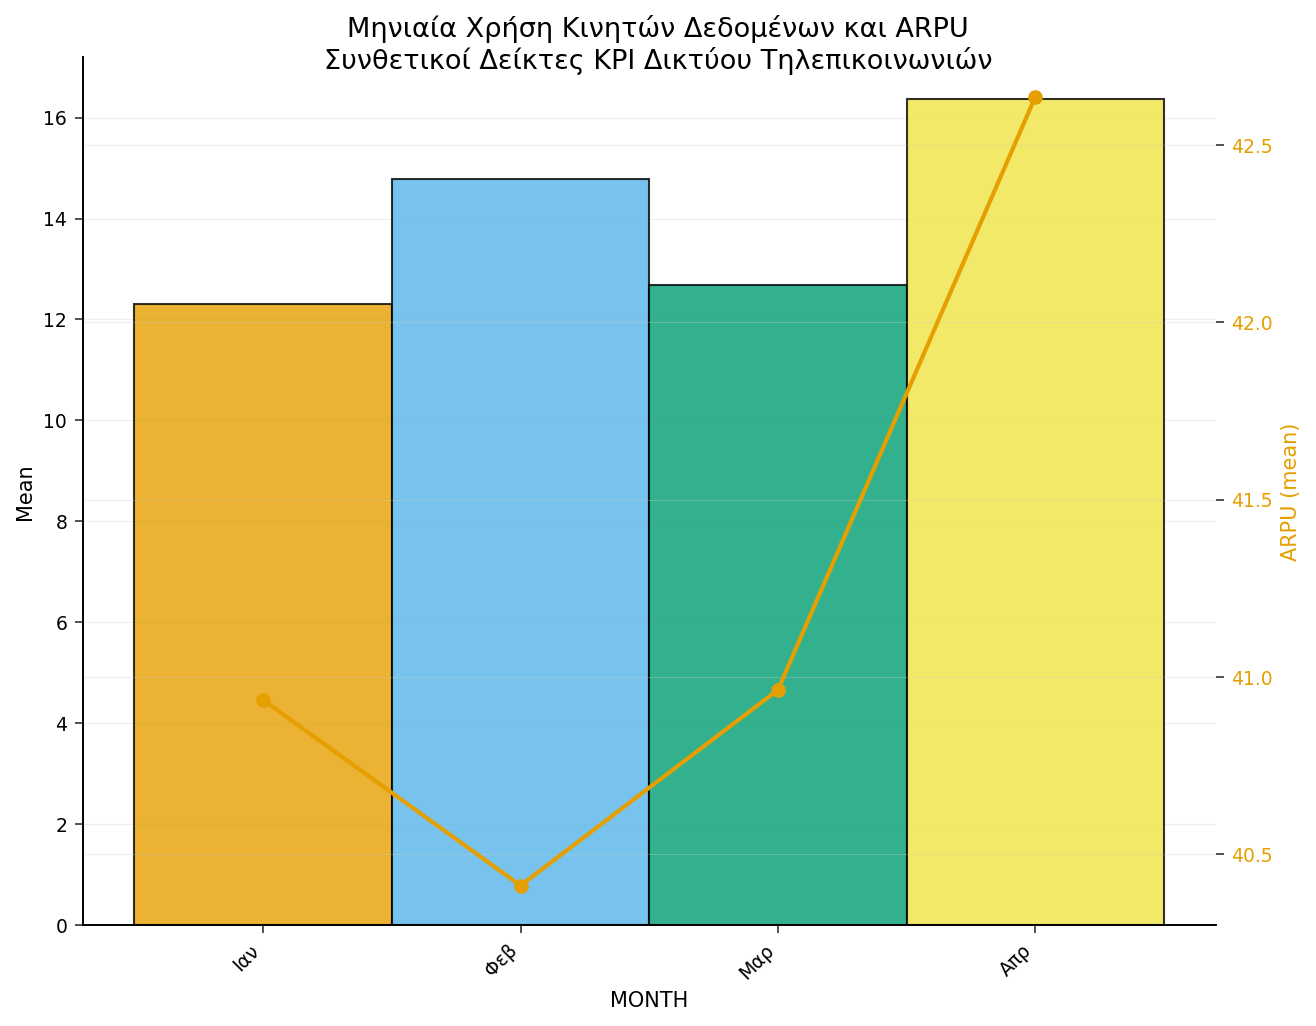

In [2]:
ODS GRAPHICS ON;
TITLE "Μηνιαία Χρήση Κινητών Δεδομένων και ARPU";
title2 "Συνθετικοί Δείκτες KPI Δικτύου Τηλεπικοινωνιών";

ΔΙΑΔΙΚΑΣΙΑ gbarline ΔΕΔΟΜΕΝΑ=telco_kpi;
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
    ΕΤΙΚΕΤΑ month="Μήνας" data_gb="Δεδομένα (GB)" arpu="ARPU ($)";
ΕΚΤΕΛΕΣΗ;


## Βήμα 3 — Ανάλυση χρήσης ανά πρόγραμμα, επικάλυψη αποχώρησης

Αντικαθιστώντας το `TYPE=mean` με `TYPE=sum` και προσθέτοντας `SUBGROUP=plan` σωρεύουμε τη ράβδο κάθε μήνα κατά επίπεδο προγράμματος, ώστε να δούμε ποιο τμήμα οδηγεί τον συνολικό όγκο. Η επικαλυπτόμενη `LINE` τώρα σχεδιάζει τον μηνιαίο **αριθμό** συμβάντων αποχώρησης ως γράφημα βελόνας (`STAT=sum TYPE=needle`) — κάθετες αιχμές που διαβάζονται φυσικά ως διακριτά μετρήματα συμβάντων αντί για ομαλή τάση.

                                   Όγκος Δεδομένων ανά Πρόγραμμα με Μηνιαία Αποχώρηση                                   
                                     Συνθετικοί Δείκτες KPI Δικτύου Τηλεπικοινωνιών                                     




NOTE: Option TITLE changed to Όγκος Δεδομένων ανά Πρόγραμμα με Μηνιαία Αποχώρηση.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


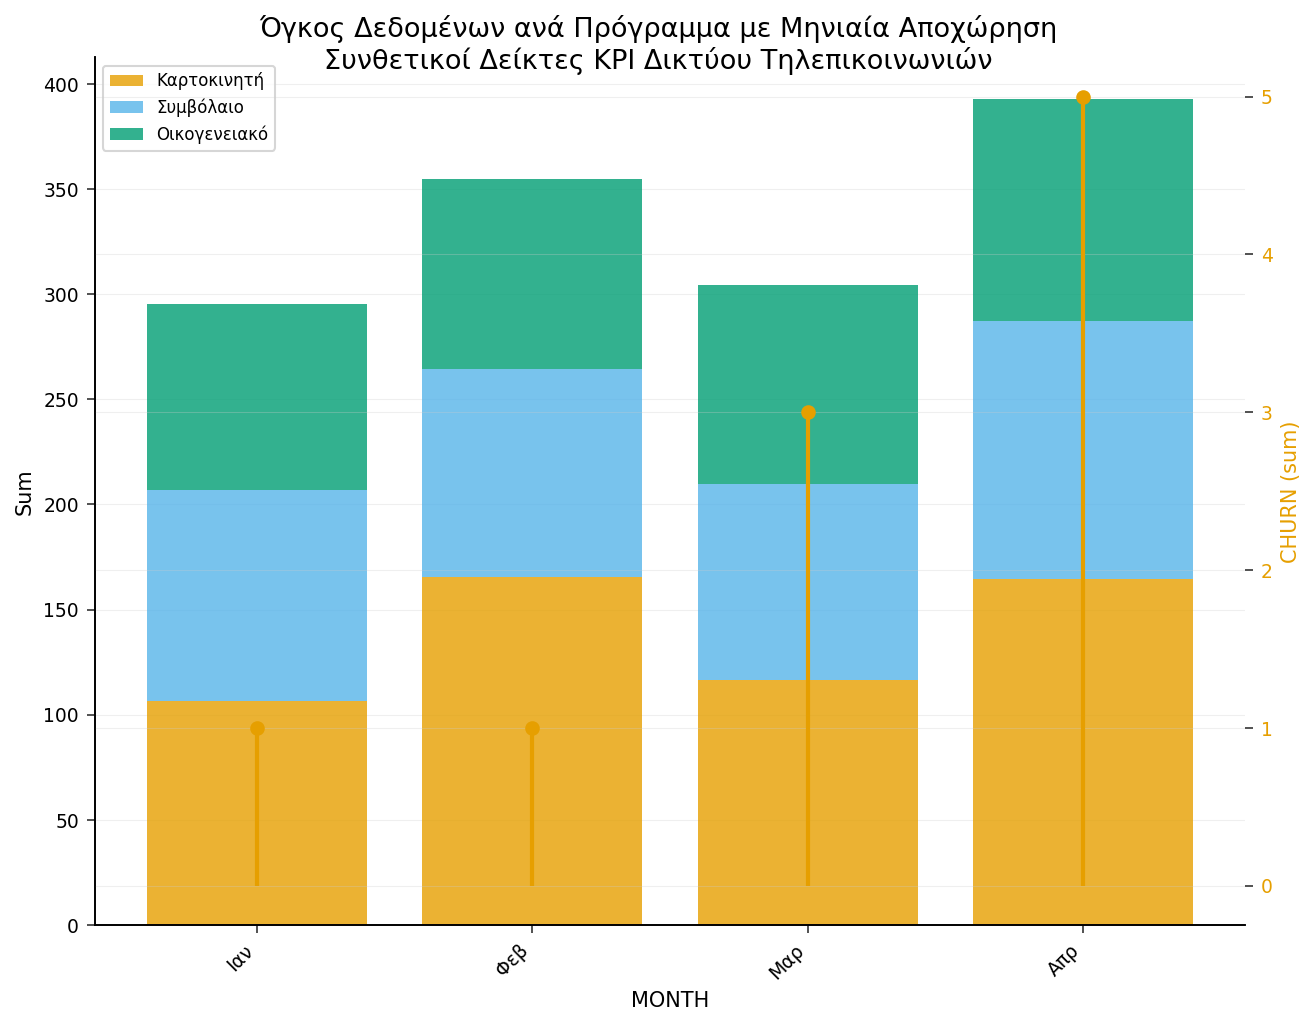

In [3]:
TITLE "Όγκος Δεδομένων ανά Πρόγραμμα με Μηνιαία Αποχώρηση";

ΔΙΑΔΙΚΑΣΙΑ gbarline ΔΕΔΟΜΕΝΑ=telco_kpi;
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
    ΕΤΙΚΕΤΑ month="Μήνας" data_gb="Δεδομένα (GB)" plan="Πρόγραμμα" churn="Αποχώρηση";
ΕΚΤΕΛΕΣΗ;


## Βήμα 4 — Έλεγχος του δεξιού άξονα και του δείκτη γραμμής

Για ένα γράφημα έτοιμο για δημοσίευση καθηλώνουμε τον (δεξιό) άξονα του γραφήματος σε ένα σταθερό εύρος με έναν ορισμό `AXIS` και τον επισημαίνουμε, στη συνέχεια τον συνδέουμε με τη γραμμή μέσω `RAXIS=axis2`. Ένας ορισμός `SYMBOL` δίνει στη γραμμή ARPU έναν κόκκινο διάστικτο δείκτη. Εμφανίζουμε επίσης τα σύνολα των ράβδων πάνω από κάθε ράβδο με `OUTSIDE=sum`.

                                   Συνολική Χρήση (ράβδοι) έναντι Μέσου ARPU (γραμμή)                                   
                                     Συνθετικοί Δείκτες KPI Δικτύου Τηλεπικοινωνιών                                     




NOTE: Option TITLE changed to Συνολική Χρήση (ράβδοι) έναντι Μέσου ARPU (γραμμή).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


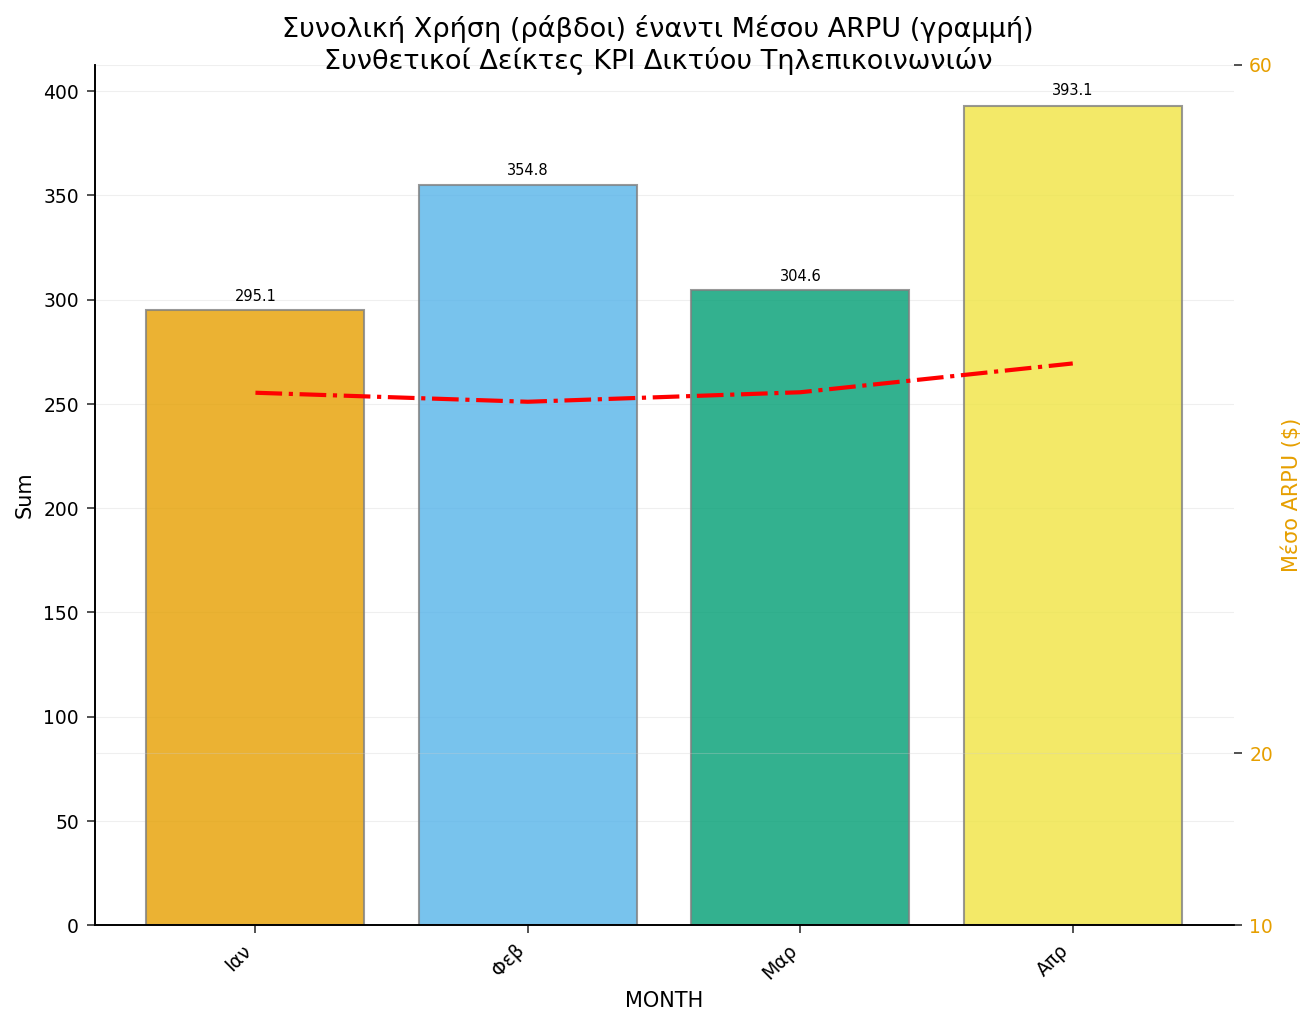

In [4]:
TITLE "Συνολική Χρήση (ράβδοι) έναντι Μέσου ARPU (γραμμή)";

ΔΙΑΔΙΚΑΣΙΑ gbarline ΔΕΔΟΜΕΝΑ=telco_kpi;
    axis2 ORDER=(20 ΕΩΣ 60 ΚΑΤΑ 10) ΕΤΙΚΕΤΑ=("Μέσο ARPU ($)");
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
    ΕΤΙΚΕΤΑ month="Μήνας" data_gb="Δεδομένα (GB)";
ΕΚΤΕΛΕΣΗ;


## Βήμα 5 — Πολλαπλές επικαλύψεις γραμμών με προσαρμοσμένο υπόμνημα

Η `GBARLINE` δέχεται περισσότερες από μία δηλώσεις `LINE`, οπότε μπορούμε να συγκρίνουμε δύο λειτουργικά σήματα έναντι των ράβδων χρήσης ταυτόχρονα: μέσα αιτήματα υποστήριξης (`type=join`) και συνολική αποχώρηση (`type=needle`). Ένας ορισμός `LEGEND` τοποθετημένος στο κάτω μέρος τεκμηριώνει τις υποομάδες προγράμματος.

                                      Τάσεις Αιτημάτων Υποστήριξης και Αποχώρησης                                       
                                     Συνθετικοί Δείκτες KPI Δικτύου Τηλεπικοινωνιών                                     




NOTE: Option TITLE changed to Τάσεις Αιτημάτων Υποστήριξης και Αποχώρησης.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


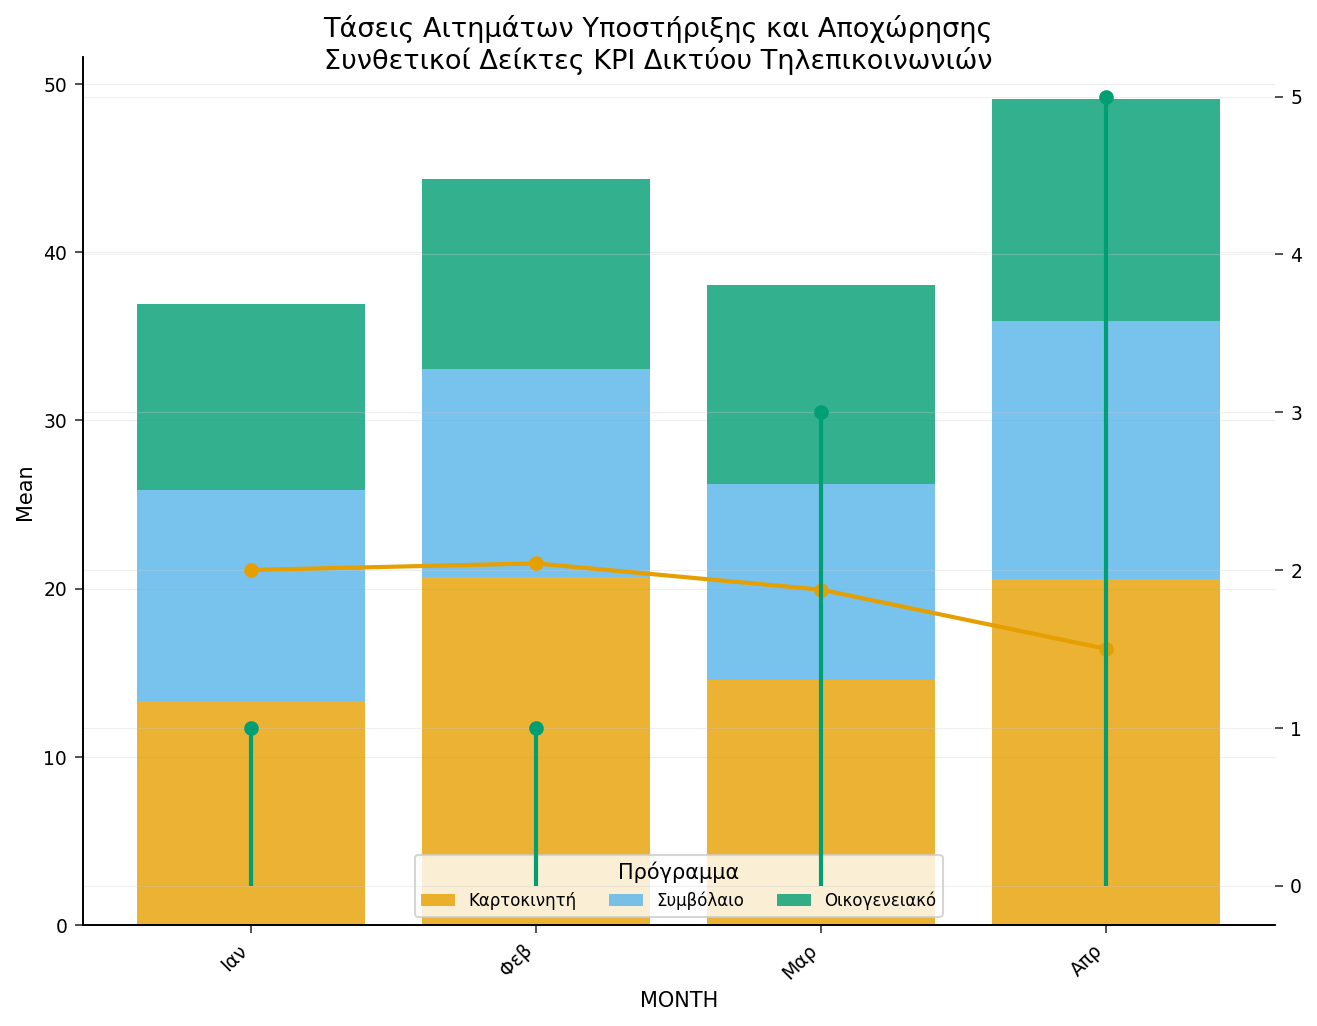

In [5]:
TITLE "Τάσεις Αιτημάτων Υποστήριξης και Αποχώρησης";

ΔΙΑΔΙΚΑΣΙΑ gbarline ΔΕΔΟΜΕΝΑ=telco_kpi;
    legend1 ΕΤΙΚΕΤΑ=("Πρόγραμμα") position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
    ΕΤΙΚΕΤΑ month="Μήνας" data_gb="Δεδομένα (GB)" plan="Πρόγραμμα" tickets="Αιτήματα Υποστήριξης" churn="Αποχώρηση";
ΕΚΤΕΛΕΣΗ;

ODS GRAPHICS OFF;


## Ερμηνεία των αποτελεσμάτων

Στο παράθυρο Ιανουαρίου–Απριλίου το dashboard αφηγείται μια συνεκτική ιστορία τηλεπικοινωνιών. Η **χρήση δεδομένων** (οι ράβδοι) είναι ασταθής μήνα προς μήνα αλλά τείνει ανοδικά, κορυφώνοντας τον **Απρίλιο** — η μέση χρήση ανεβαίνει από περίπου 12.3 GB τον Ιανουάριο σε 16.4 GB τον Απρίλιο (Βήμα 2), και ο συνολικός όγκος από 295 GB σε 393 GB (οι ετικέτες `OUTSIDE=sum` στο Βήμα 4). Η **γραμμή ARPU** πέφτει ελαφρώς τον Φεβρουάριο και μετά ανεβαίνει στη δική της κορυφή Απριλίου κοντά στα \$42.6, οπότε ο πάροχος αξιοποιεί όλο και περισσότερο οικονομικά την επιπλέον κατανάλωση αντί να την προσφέρει δωρεάν — ο δεξιός άξονας στο Βήμα 4 είναι καθηλωμένος στα \$20–\$60 για να παραμείνει αναγνώσιμη αυτή η κίνηση.

Οι σωρευμένες ανά πρόγραμμα προβολές (Βήματα 3 και 5) αποκαλύπτουν την ένταση τμημάτων που χαρακτηρίζει τους παρόχους με βαριά καρτοκινητή βάση. Η **Καρτοκινητή** (η πορτοκαλί ζώνη) μεταφέρει τα περισσότερα γιγαμπάιτ συνολικά — περίπου 553 GB στους τέσσερις μήνες έναντι 415 GB για το Συμβόλαιο και 380 GB για το Οικογενειακό — ωστόσο κερδίζει το **χαμηλότερο** μέσο έσοδο ανά χρήστη (περίπου \$36, έναντι \$41 για το Συμβόλαιο και \$47 για το Οικογενειακό). Οι **βελόνες αποχώρησης** επιβεβαιώνουν πού βρίσκεται ο κίνδυνος διατήρησης: τα συμβάντα αποχώρησης συγκεντρώνονται στα επίπεδα Καρτοκινητή και Συμβόλαιο (4 συμβάντα το καθένα στο παράθυρο) και παραμένουν ελαφρύτερα στο Οικογενειακό (2), και αυξάνονται προς τον Απρίλιο καθώς η βάση συνδρομητών και η χρήση επεκτείνονται.

Το Βήμα 5 επικαλύπτει το λειτουργικό φορτίο πάνω σε αυτό: τα μέσα **αιτήματα υποστήριξης** τρέχουν λίγο πιο βαριά νωρίς στην περίοδο και υποχωρούν μέχρι τον Απρίλιο, ενώ οι βελόνες αποχώρησης κορυφώνονται αργότερα — το είδος σήματος που παρακολουθεί μια ομάδα διατήρησης. Λειτουργικά, το συμπέρασμα είναι να συγκεντρωθούν τα έξοδα διατήρησης στους συνδρομητές **Καρτοκινητής**, οι οποίοι καταναλώνουν το ταχύτερα αναπτυσσόμενο τμήμα του όγκου δεδομένων ενώ παράγουν τα λιγότερα έσοδα και την περισσότερη αποχώρηση.

Η `PROC GBARLINE` είναι το σωστό εργαλείο εδώ ακριβώς επειδή διατηρεί τις ράβδους κλίμακας γιγαμπάιτ και τις γραμμές κλίμακας δολαρίου/μετρήματος σε ανεξάρτητους άξονες, επιτρέποντας σε κάθε KPI να διαβάζεται με τους δικούς του όρους ενώ εξακολουθεί να μοιράζεται τον μηνιαίο άξονα χρόνου.